### Regressão

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn import tree
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from matplotlib import pyplot as plt
import re

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Airbnb_NYC_2019_VF.csv")

### Teste de vários cenários com Árvores de Decisão e Redes Neuronais

In [2]:
df['interaction'] = df['availability_365'] * df['minimum_nights']

scenarios = [
    ("Scenario 1", df[['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood_group']], df['price']),
    ("Scenario 2", df[['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood_group', 'number_of_reviews']], df['price']),
    ("Scenario 3", df[['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood_group', 'number_of_reviews', 'availability_365', 'minimum_nights']], df['price']),
    ("Scenario 4", df[['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood_group', 'number_of_reviews', 'availability_365', 'minimum_nights', 'serious_crimes']], df['price']),
    ("Scenario 5", df[['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood_group', 'number_of_reviews', 'availability_365', 'minimum_nights', 'serious_crimes', 'attractions']], df['price']),
    ("Scenario 6", df[['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood_group', 'number_of_reviews', 'availability_365', 'minimum_nights', 'attractions']], df['price']),
    ("Scenario 7", df[['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood_group', 'number_of_reviews', 'availability_365', 'minimum_nights', 'interaction']], df['price']),
    ("Scenario 8", df[['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood']], df['price']),
    ("Scenario 9", df[['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood', 'number_of_reviews', 'availability_365', 'minimum_nights', 'attractions']], df['price']),
    ("Scenario 10", df[['room_type_Entire.home.apt', 'room_type_Private.room', 'room_type_Shared.room', 'neighbourhood', 'minimum_nights']], df['price'])
]

##### 70% treino e 30% teste

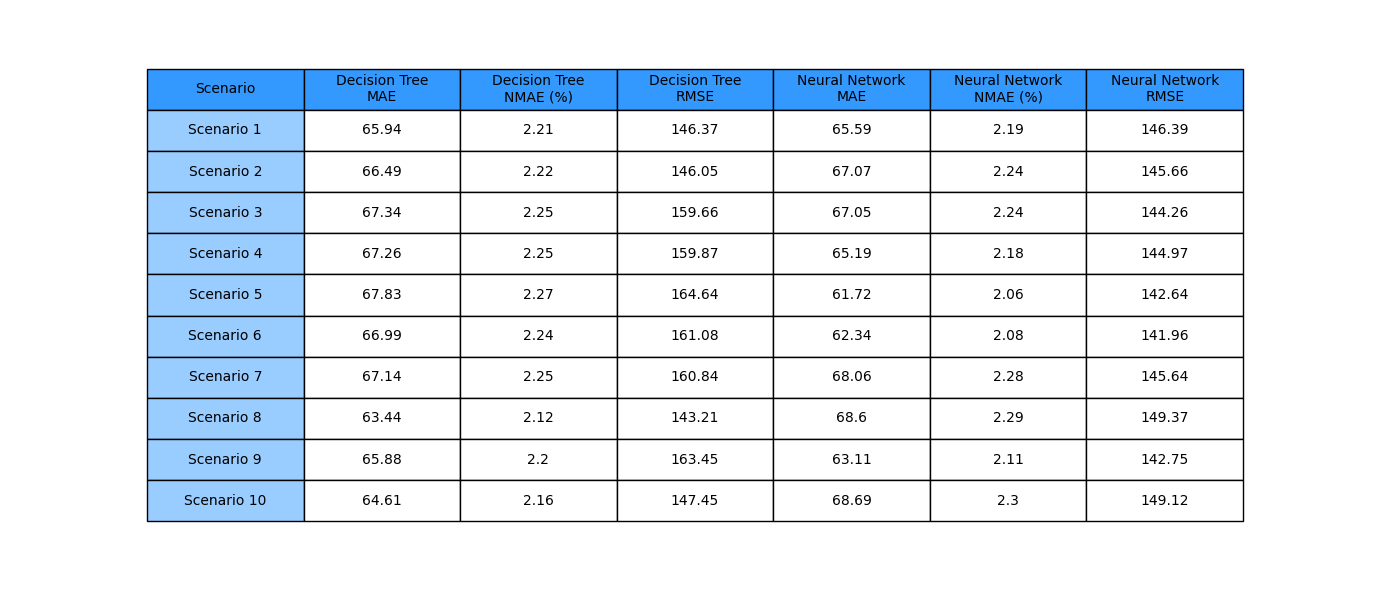

In [3]:
accuracies = []
data_table = []

saved_results = {}

for name_scenario, X, y in scenarios:
    Xtr, Xts, ytr, yts = train_test_split(X, y, test_size=0.3, random_state=42)

    # ----- Decision Tree -----
    dt = tree.DecisionTreeRegressor(max_depth=12, random_state=42)
    dt.fit(Xtr, ytr)
    prev_dt = dt.predict(Xts)
    mae_dt = mean_absolute_error(yts, prev_dt)
    nmae_dt = (mae_dt / (yts.max() - yts.min())) * 100
    rmse_dt = np.sqrt(mean_squared_error(yts, prev_dt))

    # ----- Neural Network -----
    nn = MLPRegressor(hidden_layer_sizes=[10,5,2], max_iter=900, random_state=42)
    nn.fit(Xtr, ytr)
    prev_nn = nn.predict(Xts)
    mae_nn = mean_absolute_error(yts, prev_nn)
    nmae_nn = (mae_nn / (yts.max() - yts.min())) * 100
    rmse_nn = np.sqrt(mean_squared_error(yts, prev_nn))
    
    accuracies.append([
        name_scenario,
        nmae_dt,
        nmae_nn
    ])

    data_table.append([
        name_scenario,
        round(mae_dt, 2), round(nmae_dt, 2), round(rmse_dt, 2),
        round(mae_nn, 2), round(nmae_nn, 2), round(rmse_nn, 2)
    ])

    saved_results[name_scenario] = {
        'yts': yts,
        'prev_dt': prev_dt,
        'prev_nn': prev_nn
    }

columns_accuracies = pd.MultiIndex.from_tuples([
    ("Scenario", ""),
    ("Decision Tree", "NMAE (%)"),
    ("Neural Network", "NMAE (%)")
])
df_accuracies = pd.DataFrame(accuracies, columns=columns_accuracies)

columns = pd.MultiIndex.from_tuples([
    ("Scenario", ""),
    ("Decision Tree", "MAE"),
    ("Decision Tree", "NMAE (%)"),
    ("Decision Tree", "RMSE"),
    ("Neural Network", "MAE"),
    ("Neural Network", "NMAE (%)"),
    ("Neural Network", "RMSE")
])
df_results = pd.DataFrame(data_table, columns=columns)

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

table = ax.table(cellText=df_results.values,
                  colLabels=[f'{a}\n{b}' if b else a for a, b in df_results.columns],
                  loc='center',
                  cellLoc='center',
                  colLoc='center',
                  colColours=["#3399FF"]*len(df_results.columns))

table.scale(0.8, 2)
table.auto_set_font_size(False)
table.set_fontsize(10)

for row in range(1, len(df_results) + 1):
    table[row, 0].set_facecolor("#99CCFF")

plt.tight_layout()
plt.show()

##### 5-fold cross-validation

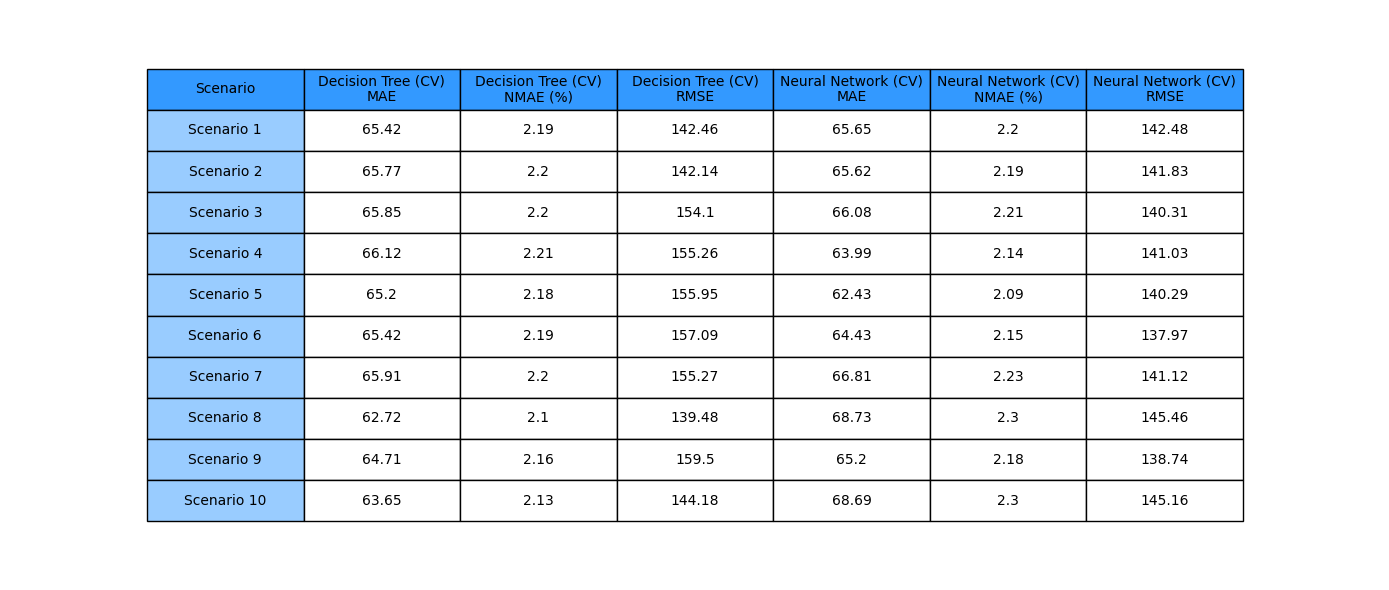

In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

accuracies_kfold = []
data_table_kfold = []

saved_results_kfold = {}

for name_scenario, X, y in scenarios:
    X_vals = X.values
    y_vals = y.values

    mae_dt_list = []
    nmae_dt_list = []
    rmse_dt_list = []

    mae_nn_list = []
    nmae_nn_list = []
    rmse_nn_list = []
    
    all_yts = []
    all_pred_dt = []
    all_pred_nn = []

    for train_idx, test_idx in kf.split(X_vals):
        Xtr, Xts = X_vals[train_idx], X_vals[test_idx]
        ytr, yts = y_vals[train_idx], y_vals[test_idx]

        # ----- Decision Tree -----
        dt = tree.DecisionTreeRegressor(max_depth=12, random_state=42)
        dt.fit(Xtr, ytr)
        pred_dt = dt.predict(Xts)
        mae_dt = mean_absolute_error(yts, pred_dt)
        nmae_dt = (mae_dt / (yts.max() - yts.min())) * 100
        rmse_dt = np.sqrt(mean_squared_error(yts, pred_dt))
        mae_dt_list.append(mae_dt)
        nmae_dt_list.append(nmae_dt)
        rmse_dt_list.append(rmse_dt)

        # ----- Neural Network -----
        nn = MLPRegressor(hidden_layer_sizes=[10,5,2], max_iter=900, random_state=42)
        nn.fit(Xtr, ytr)
        pred_nn = nn.predict(Xts)
        mae_nn = mean_absolute_error(yts, pred_nn)
        nmae_nn = (mae_nn / (yts.max() - yts.min())) * 100
        rmse_nn = np.sqrt(mean_squared_error(yts, pred_nn))
        mae_nn_list.append(mae_nn)
        nmae_nn_list.append(nmae_nn)
        rmse_nn_list.append(rmse_nn)
        
        all_yts.extend(yts)
        all_pred_dt.extend(pred_dt)
        all_pred_nn.extend(pred_nn)

    accuracies_kfold.append([
        name_scenario,
        float(np.mean(nmae_dt_list)),
        float(np.mean(nmae_nn_list))
    ])

    data_table_kfold.append([
        name_scenario,
        round(np.mean(mae_dt_list), 2),
        round(np.mean(nmae_dt_list), 2),
        round(np.mean(rmse_dt_list), 2),
        round(np.mean(mae_nn_list), 2),
        round(np.mean(nmae_nn_list), 2),
        round(np.mean(rmse_nn_list), 2),
    ])
    
    saved_results_kfold[name_scenario] = {
        'yts': np.array(all_yts),
        'prev_dt': np.array(all_pred_dt),
        'prev_nn': np.array(all_pred_nn)
    }

columns_accuracies_kfold = pd.MultiIndex.from_tuples([
    ("Scenario", ""),
    ("Decision Tree (CV)", "NMAE (%)"),
    ("Neural Network (CV)", "NMAE (%)")
])
df_accuracies_kfold = pd.DataFrame(accuracies_kfold, columns=columns_accuracies_kfold)

columns_kfold = pd.MultiIndex.from_tuples([
    ("Scenario", ""),
    ("Decision Tree (CV)", "MAE"),
    ("Decision Tree (CV)", "NMAE (%)"),
    ("Decision Tree (CV)", "RMSE"),
    ("Neural Network (CV)", "MAE"),
    ("Neural Network (CV)", "NMAE (%)"),
    ("Neural Network (CV)", "RMSE"),
])
df_kfold_results = pd.DataFrame(data_table_kfold, columns=columns_kfold)

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

table = ax.table(cellText=df_kfold_results.values,
                 colLabels=[f"{a}\n{b}" if b else a for a, b in df_kfold_results.columns],
                 loc='center',
                 cellLoc='center',
                 colLoc='center',
                 colColours=["#3399FF"] * len(df_kfold_results.columns))

table.scale(0.8, 2)
table.auto_set_font_size(False)
table.set_fontsize(10)

for row in range(1, len(df_kfold_results) + 1):
    table[row, 0].set_facecolor("#99CCFF")

plt.tight_layout()
plt.show()

##### melhores cenários

In [5]:
df_split = df_accuracies.copy()
df_kfold = df_accuracies_kfold.copy()

def stack_all_results(df_split, df_kfold):
    results = []

    for df, suffix in [(df_split, ""), (df_kfold, " (CV)")]:
        for model in ["Decision Tree", "Neural Network"]:
            col_name = (model + suffix, "NMAE (%)")
            if col_name in df.columns:
                for _, row in df.iterrows():
                    scenario_raw = row[("Scenario", "")]
                    match = re.search(r"\d+", str(scenario_raw))
                    if not match:
                        continue
                    scenario_num = int(match.group())
                    results.append({
                        "Scenario": scenario_num,
                        "Model": model,
                        "NMAE": row[col_name],
                        "Suffix": suffix,
                        "Source": "kfold" if suffix else "split"
                    })

    return pd.DataFrame(results)

all_results = stack_all_results(df_split, df_kfold)

top2 = all_results.sort_values("NMAE").head(2)

print("Best scenarios:")

best = {}

for i, row in top2.iterrows():
    scenario_num = row["Scenario"]
    scenario_str = f"Scenario {scenario_num} - {row['Model']}{row['Suffix']}"
    print(scenario_str)

    df = df_kfold if row["Suffix"] == " (CV)" else df_split
    match_row = df[df[("Scenario", "")] == f"Scenario {scenario_num}"].iloc[0]
    best[scenario_num] = {
    "row": match_row,
    "model": row["Model"],
    "suffix": row["Suffix"]
}

Best scenarios:
Scenario 5 - Neural Network
Scenario 6 - Neural Network


### RSC para os melhores cenários

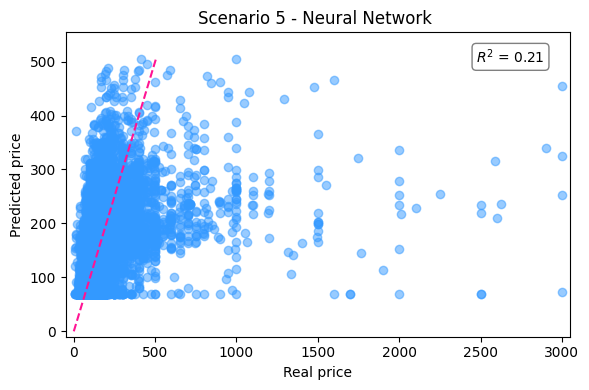

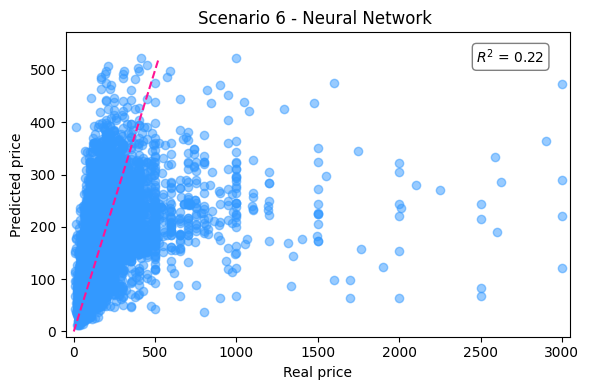

In [6]:
# ----- RSC plotting -----
plot = set()

for scenario, data in best.items():
    best_row = data["row"]
    model = data["model"]
    suffix = data["suffix"]
    
    if scenario in plot:
        continue

    plot.add(scenario)

    key = f"Scenario {scenario}"
    match = df_kfold[df_kfold[("Scenario", "")] == key]
    if not match.empty and best_row.equals(match.iloc[0]):
        result_dict = saved_results_kfold.get(key)
        suffix = " (CV)"
    else:
        result_dict = saved_results.get(key)

    yts = result_dict["yts"]

    if model == "Decision Tree":
        prev = result_dict["prev_dt"]
        r2 = r2_score(yts, prev)
        title = f"Scenario {scenario} - Decision Tree {suffix}"
    elif model == "Neural Network":
        prev = result_dict["prev_nn"]
        r2 = r2_score(yts, prev)
        title = f"Scenario {scenario} - Neural Network {suffix}"
    else:
        continue

    plt.figure(figsize=(6, 4))
    plt.scatter(yts, prev, alpha=0.5, color="#3399FF")
    xmax = yts.max()
    ymax = prev.max()
    lim = min(xmax, ymax)
    x_vals = np.linspace(0, lim, 100)
    plt.plot(x_vals, x_vals, color="#FF1493", linestyle="--")
    plt.xlim(-50, xmax + 50)
    plt.ylim(-10, ymax + 50)
    plt.xlabel("Real price")
    plt.ylabel("Predicted price")
    plt.title(title)
    plt.text(0.95, 0.95, f"$R^2$ = {r2:.2f}", transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
    plt.tight_layout()
    plt.show()

### Curvas REC

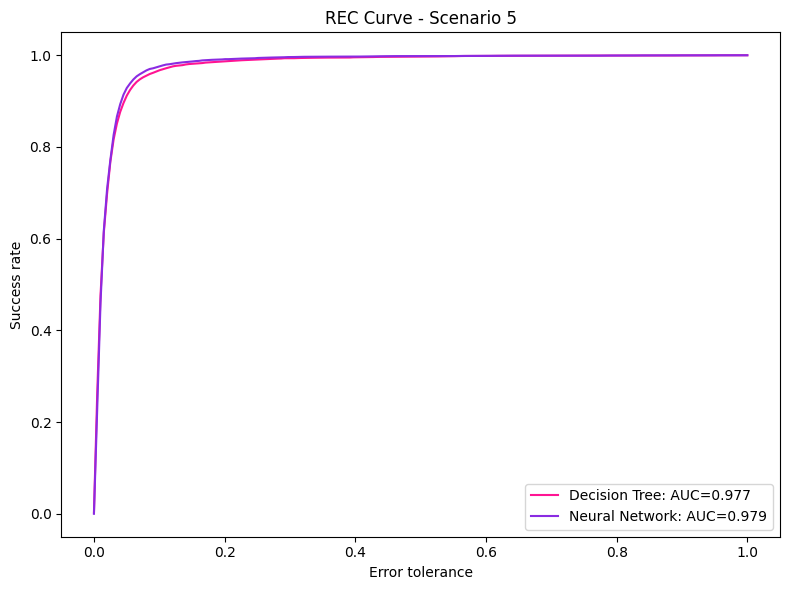

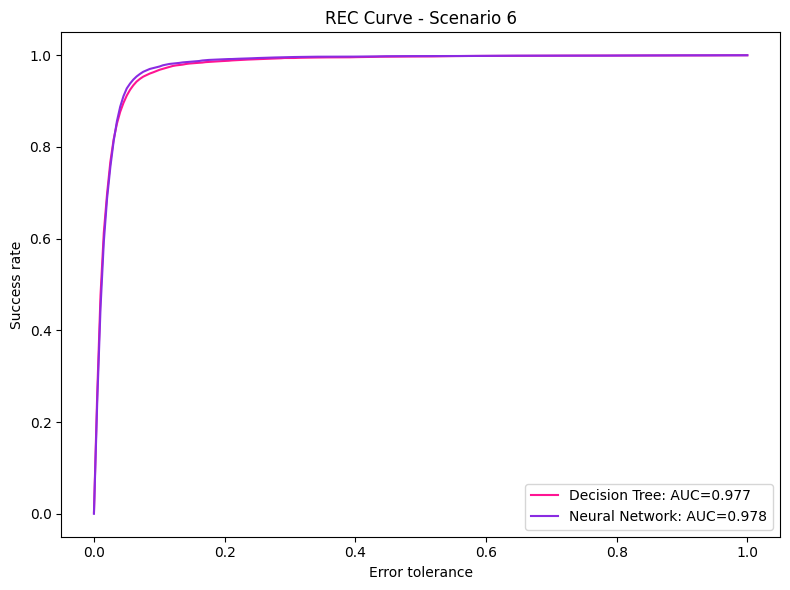

In [8]:
# ----- REC Curve -----
def plot_rec_curve(y_true, y_pred, label_base, color):
    abs_errors = np.abs(y_true - y_pred)
    max_error = abs_errors.max()
    thresholds = np.linspace(0, 1, 200)  # Normalizado de 0 a 1
    coverage = [np.mean(abs_errors <= t * max_error) for t in thresholds]
    auc_score = np.trapezoid(coverage, thresholds)
    label = f'{label_base}: AUC={auc_score:.3f}'
    plt.plot(thresholds, coverage, label=label, color=color)

colors = {
    'Decision Tree': "#FF1493",
    'Neural Network': '#8A2BE2'
}

plot = set()

for scenario, data in best.items():
    best_row = data["row"]
    suffix = data["suffix"]
    
    if scenario in plot:
        continue

    plot.add(scenario)

    key = f"Scenario {scenario}"
    match = df_kfold[df_kfold[("Scenario", "")] == key]
    if not match.empty and best_row.equals(match.iloc[0]):
        result_dict = saved_results_kfold.get(key)
        suffix = " (CV)"
    else:
        result_dict = saved_results.get(key)
        suffix = ""

    if result_dict is None:
        print(f"Warning: no saved results for {key}")
        continue

    yts = result_dict["yts"]
    prev_dt = result_dict["prev_dt"]
    prev_nn = result_dict["prev_nn"]

    plt.figure(figsize=(8, 6))
    plot_rec_curve(yts, prev_dt, f"Decision Tree{suffix}", colors['Decision Tree'])
    plot_rec_curve(yts, prev_nn, f"Neural Network{suffix}", colors['Neural Network'])

    plt.title(f"REC Curve - Scenario {scenario}{suffix}")
    plt.xlabel('Error tolerance')
    plt.ylabel('Success rate')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()